# Gaussian Process

This demo shows how to use GaussianProcessRegressor on a simple 1D sine-like function with and without derivative observations.

In [1]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sys.path.append("../..")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware

from utils import plot_gpr

The first step is to specify the function to regress. In this case, we regress a simple 1D noisy function with three turning points.

In [2]:
def F(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return X * np.sin(4*np.pi * X**2) + s

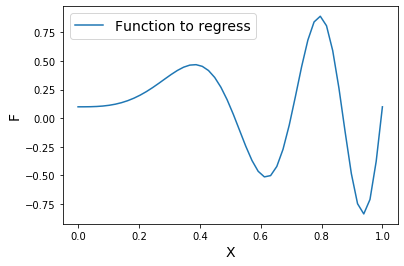

In [3]:
np.random.seed(1)

X_lower = 0 
X_upper = 1
X_star = np.linspace(X_lower, X_upper, 50)
y_star = F(X_star, s=0.1)

plt.plot(X_star, y_star, label='Function to regress')
plt.xlabel("X", fontsize=14)
plt.ylabel("F", fontsize=14)
plt.legend(fontsize=14)
plt.savefig("toy_func.png", bbox_inches='tight')
plt.show()

## Regular GPR

Now we attempt to regress the function using regular GPR.

Five random points are chosen to train the GPR.

For reproducible results, enter an integer > 0 random state.

In [4]:
np.random.seed(123)
X_train = np.random.uniform(X_lower, X_upper, 5)
y_train = F(X_train)

MSE :  0.13443561555932426
Uncert :  2.3965322122800328


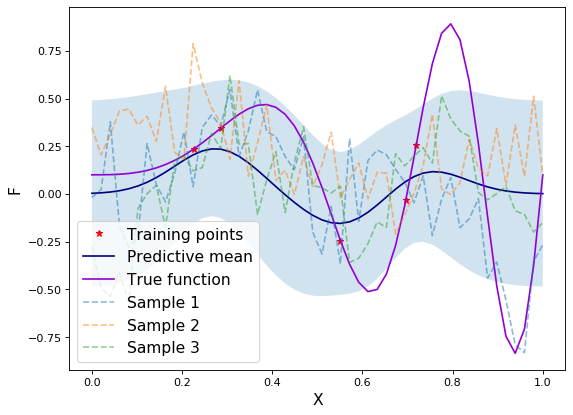

In [5]:
kernel = GPKernel()
gpr = GaussianProcessRegressor(kernel=kernel,
                               n_restarts_optimizer=10,
                               random_state=123)
gpr.fit(X_train.reshape(-1, 1), y_train)

# predict X_star
mu, cov = gpr.predict(X_star.reshape(-1, 1), return_cov=True)
_, std = gpr.predict(X_star.reshape(-1, 1), return_std=True)

mse = mean_squared_error(y_star, mu)
print("MSE : ", mse)
print("Uncert : ", np.trace(cov))

nsamples = 3
samples = np.random.multivariate_normal(mu, cov, nsamples)

plot_gpr(X_train=X_train, y_train=y_train, 
         X_true=X_star, y_true=y_star, 
         y_pred=mu, std_pred=std, samples=samples, 
         save_to="regular_gpr.png")

## Derivative-enhanced GPR\

And now we use derivative information to aid the GPR.

In [6]:
def dF(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return np.sin(4*np.pi * X**2) + X * np.cos(4*np.pi * X**2) * (8*np.pi * X) + s

In [7]:
dX_train = X_train
dy_train = dF(dX_train)

dX_star = X_star
dy_star = dF(X_star)

MSE :  0.17728591714682004
Uncert :  2.304317557172023


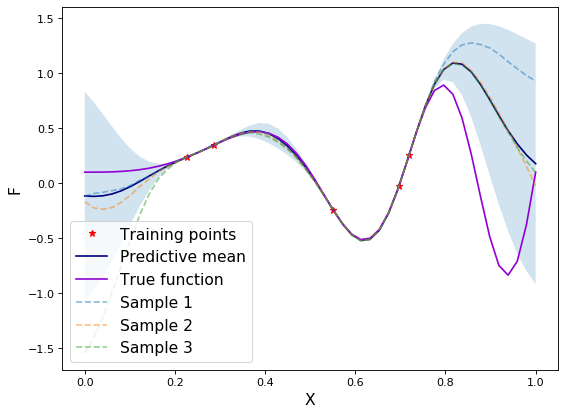

In [8]:
kernel = GPKernelDerAware()
gpr = GaussianProcessRegressor(kernel=kernel,
                               n_restarts_optimizer=10,
                               random_state=123)
gpr.fit(X_train.reshape(-1, 1), y_train,
        dX_train.reshape(-1, 1), dy_train,)

# predict X_star
mu, cov = gpr.predict(X_star.reshape(-1, 1), return_cov=True)
_, std = gpr.predict(X_star.reshape(-1, 1), return_std=True)

mse = mean_squared_error(y_star, mu)
print("MSE : ", mse)
print("Uncert : ", np.trace(cov))

nsamples = 3
samples = np.random.multivariate_normal(mu, cov, nsamples)

plot_gpr(X_train=X_train, y_train=y_train, 
         X_true=X_star, y_true=y_star, 
         y_pred=mu, std_pred=std, samples=samples, 
         save_to="derenhanced_gpr.png")

If needed, we can also predict the derivative observations by calling gpr.predict_der()

MSE :  55.65388322456779
Uncert :  453.8445495250286


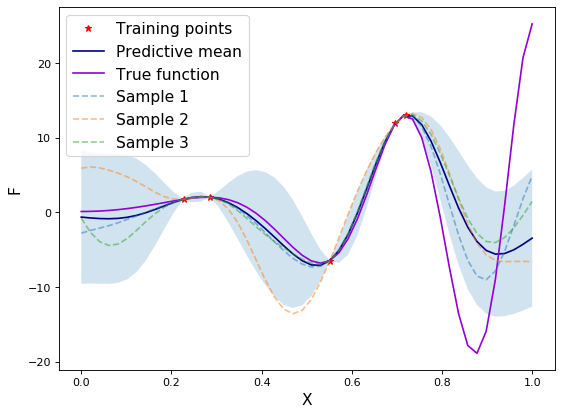

In [9]:
mu_der, cov_der = gpr.predict_der(dX_star.reshape(-1, 1), return_cov=True)
_, std_der = gpr.predict_der(dX_star.reshape(-1, 1), return_std=True)

mse_der = mean_squared_error(dy_star, mu_der)
print("MSE : ", mse_der)
print("Uncert : ", np.trace(cov_der))

nsamples = 3
samples = np.random.multivariate_normal(mu_der, cov_der, nsamples)

plot_gpr(X_train=dX_train, y_train=dy_train,
         X_true=dX_star, y_true=dy_star, 
         y_pred=mu_der, std_pred=std_der, samples=samples, 
         save_to="derenhanced_pred_grads.png")